# Import modules & packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
import plotly.express as px
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.models import Model
from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN
from keras.layers import Dense, Dropout, LSTM

# Data Import

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Nakib and Ayan/Dataset/fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# EDA

In [ ]:
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df.shape

(17880, 18)

In [ ]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


fraudulent
0    17014
1      866
Name: count, dtype: int64


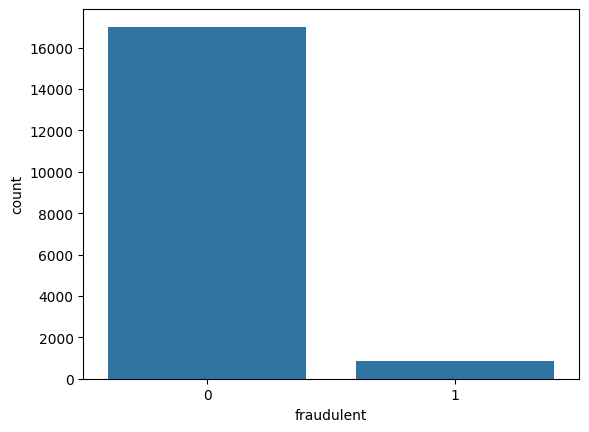

In [ ]:
print(df.fraudulent.value_counts())
sns.countplot(data=df, x='fraudulent');

In [ ]:
df.duplicated(subset='job_id').sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
df['fraudulent'].isna().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
job_id,17880
title,11231
location,3105
department,1337
salary_range,874
company_profile,1709
description,14801
requirements,11967
benefits,6204
telecommuting,2


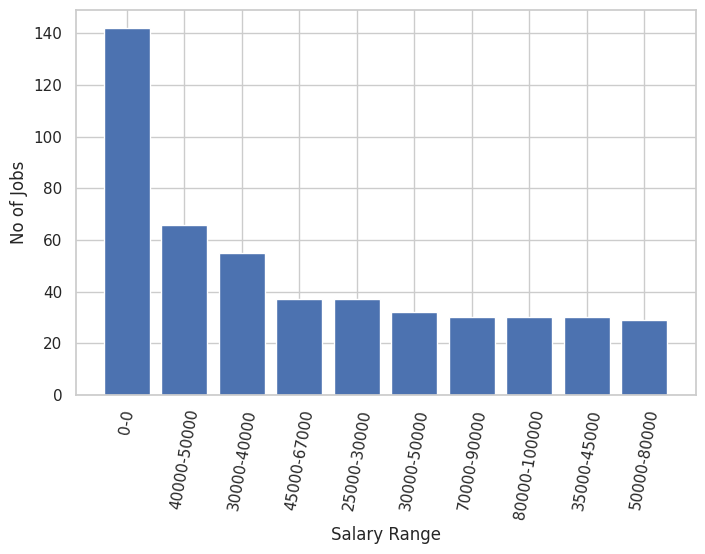

In [ ]:
salary_range = dict(df.salary_range.value_counts().head(10))


plt.figure(figsize=(8,5))
sns.set_theme(style='whitegrid')
plt.bar(salary_range.keys(),salary_range.values())
plt.xlabel("Salary Range")
plt.ylabel("No of Jobs")
plt.xticks(rotation=80)
plt.show()

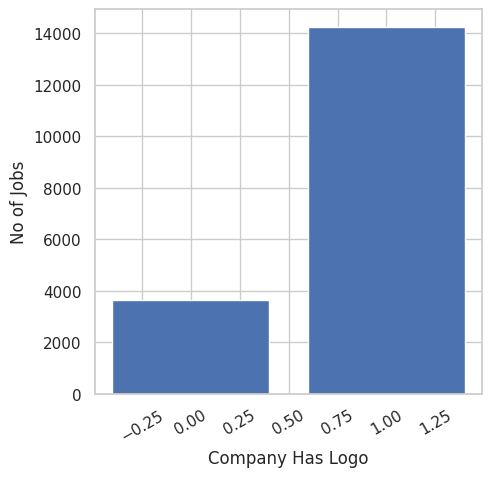

In [ ]:
has_email = dict(df.has_company_logo.value_counts().head(10))

plt.figure(figsize=(5,5))
sns.set_theme(style='whitegrid')
plt.bar(has_email.keys(),has_email.values())
plt.xlabel("Company Has Logo")
plt.ylabel("No of Jobs")
plt.xticks(rotation=30)
plt.show()

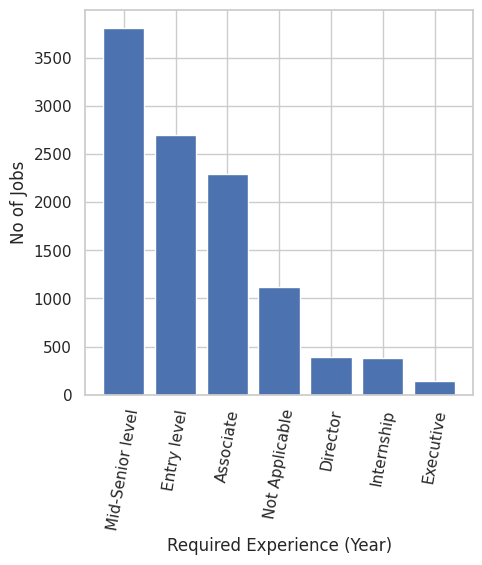

In [ ]:
required_exp = dict(df.required_experience.value_counts().head(10))

plt.figure(figsize=(5,5))
sns.set_theme(style='whitegrid')
plt.bar(required_exp.keys(),required_exp.values())
plt.xlabel("Required Experience (Year)")
plt.ylabel("No of Jobs")
plt.xticks(rotation=80)
plt.show()

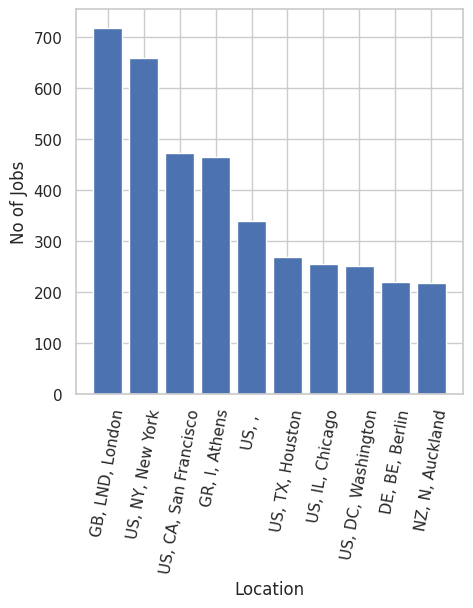

In [ ]:

location = dict(df.location.value_counts().head(10))

plt.figure(figsize=(5,5))
sns.set_theme(style='whitegrid')
plt.bar(location.keys(),location.values())
plt.xlabel("Location")
plt.ylabel("No of Jobs")
plt.xticks(rotation=80)
plt.show()

In [ ]:
print(df[df.fraudulent == 1].title.value_counts().head(15))

title
Data Entry Admin/Clerical Positions - Work From Home                    21
Cruise Staff Wanted *URGENT*                                            21
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Customer Service Representative                                         17
Administrative Assistant                                                16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Account Sales Managers $80-$130,000/yr                                  10
Payroll Data Coordinator Positions - Earn $100-$200 Daily               10
Network Marketing                                                       10
Payroll Clerk                                                           10
Agency Sales Managers $150-$175,000/yr                                   9
Data Entry                                                               9
Lawn and Maintenance Contractors                                         6
Call Center Represe

In [ ]:
print(df[df.fraudulent == 0].title.value_counts().head(15))

title
English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conversational)    144
English Teacher Abroad                                 95
Software Engineer                                      86
English Teacher Abroad (Conversational)                83
Customer Service Associate - Part Time                 76
Account Manager                                        73
Web Developer                                          66
Project Manager                                        62
Beauty & Fragrance consultants needed                  60
Graduates: English Teacher Abroad                      57
Product Manager                                        47
Marketing Manager                                      45
Web Designer                                           44
Name: count, dtype: int64


In [ ]:
print(df[df.fraudulent == 1].salary_range.value_counts().head(10))

salary_range
7200-1380000     10
30000-50000       8
250000-500000     7
28000-32000       6
35000-40000       6
70000-80000       5
21-63000          5
1000-2000         5
23000-28000       5
65000-75000       5
Name: count, dtype: int64


In [ ]:
print(df[df.fraudulent == 0].salary_range.value_counts().head(10))

salary_range
0-0             138
40000-50000      65
30000-40000      51
45000-67000      37
25000-30000      32
80000-100000     30
70000-90000      30
50000-80000      29
55000-75000      28
50000-70000      28
Name: count, dtype: int64


In [ ]:
import numpy as np


numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

print(corr_matrix)


                    job_id  telecommuting  has_company_logo  has_questions  \
job_id            1.000000      -0.004559         -0.014539      -0.087025   
telecommuting    -0.004559       1.000000         -0.019836       0.020345   
has_company_logo -0.014539      -0.019836          1.000000       0.233932   
has_questions    -0.087025       0.020345          0.233932       1.000000   
fraudulent        0.079872       0.034523         -0.261971      -0.091627   

                  fraudulent  
job_id              0.079872  
telecommuting       0.034523  
has_company_logo   -0.261971  
has_questions      -0.091627  
fraudulent          1.000000  


In [ ]:
import numpy as np

numeric_df = df[
    ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
]

corr_matrix = numeric_df.corr()
print(corr_matrix)


                  telecommuting  has_company_logo  has_questions  fraudulent
telecommuting          1.000000         -0.019836       0.020345    0.034523
has_company_logo      -0.019836          1.000000       0.233932   -0.261971
has_questions          0.020345          0.233932       1.000000   -0.091627
fraudulent             0.034523         -0.261971      -0.091627    1.000000


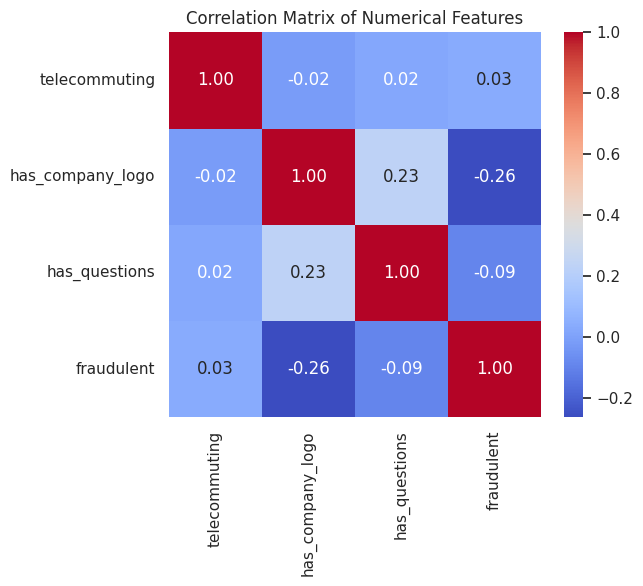

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [ ]:
df.dtypes


,0
job_id,int64
title,object
location,object
department,object
salary_range,object
company_profile,object
description,object
requirements,object
benefits,object
telecommuting,int64


# Dataset Preprocessing

In [ ]:
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df.drop(['job_id'],axis=1,inplace=True)
df.head(3)

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df.columns


Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
df.shape

(17880, 17)

In [ ]:
df.isna().sum()

,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0
has_company_logo,0


In [ ]:
df.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
df.drop(['location','telecommuting','function','industry','department'],axis=1,inplace=True)

**Taking avg of salary range colum**

In [ ]:
df.salary_range.value_counts().head(20)

,count
salary_range,
0-0,142
40000-50000,66
30000-40000,55
45000-67000,37
25000-30000,37
30000-50000,32
70000-90000,30
80000-100000,30
35000-45000,30


In [ ]:
df['salary_range'] = df['salary_range'].str.lower()
df['salary_range'] = df['salary_range'].str.strip()
df['salary_range'] = df['salary_range'].str.replace('\n', '')
df['salary_range'] = df['salary_range'].str.replace('\r', '')
df['salary_range'] = df['salary_range'].str.replace(',', '')
df['salary_range'] = df['salary_range'].str.replace('/', '')
df['salary_range'] = df['salary_range'].str.replace(' ', '')
df['salary_range'] = df['salary_range'].str.replace('–', ':')
df['salary_range'] = df['salary_range'].str.replace('-', ':')
#df['salary_range'] = df['salary_range'].str.replace('negotiable', '1')

In [ ]:
df.head(3)

,title,salary_range,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,fraudulent
0,Marketing Intern,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,1,0,Other,Internship,NaN,0
1,Customer Service - Cloud Video Production,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,1,0,Full-time,Not Applicable,NaN,0
2,Commissioning Machinery Assistant (CMA),NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,1,0,NaN,NaN,NaN,0


In [ ]:
def calculate_average(salary_range):
  try:
    if isinstance(salary_range, str) and ':' in salary_range and salary_range.strip() != '':
        min_salary, max_salary = map(int, salary_range.split(':'))
        return (min_salary + max_salary) / 2
    elif ':' not in salary_range:
        return salary_range
    else:
      return salary_range
  except:
    return salary_range


In [ ]:
df['salary_range'] = df['salary_range'].apply(calculate_average)

In [ ]:
df['salary_range'] = pd.to_numeric(df['salary_range'], errors='coerce')

In [ ]:
df['salary_range'].median()

45000.0

In [ ]:
df['salary_range'].fillna(df['salary_range'].median(), inplace=True)

/tmp/ipython-input-489958483.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary_range'].fillna(df['salary_range'].median(), inplace=True)


In [ ]:
df.head(5)

,title,salary_range,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,fraudulent
0,Marketing Intern,45000.0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,1,0,Other,Internship,NaN,0
1,Customer Service - Cloud Video Production,45000.0,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,1,0,Full-time,Not Applicable,NaN,0
2,Commissioning Machinery Assistant (CMA),45000.0,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,1,0,NaN,NaN,NaN,0
3,Account Executive - Washington DC,45000.0,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,1,0,Full-time,Mid-Senior level,Bachelor's Degree,0
4,Bill Review Manager,45000.0,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,1,1,Full-time,Mid-Senior level,Bachelor's Degree,0


In [ ]:
df.salary_range.value_counts().head(20)

,count
salary_range,
45000.0,15131
0.0,142
65000.0,81
35000.0,76
40000.0,75
50000.0,69
55000.0,63
70000.0,61
30000.0,58


In [ ]:
df.fillna(" ", inplace=True)

In [ ]:
df.isna().sum()

,0
title,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
has_company_logo,0
has_questions,0
employment_type,0
required_experience,0


In [ ]:
df.columns

Index(['title', 'salary_range', 'company_profile', 'description',
       'requirements', 'benefits', 'has_company_logo', 'has_questions',
       'employment_type', 'required_experience', 'required_education',
       'fraudulent'],
      dtype='object')

In [ ]:
df.salary_range = df.salary_range.astype(float)

In [ ]:
df.dtypes

,0
title,object
salary_range,float64
company_profile,object
description,object
requirements,object
benefits,object
has_company_logo,int64
has_questions,int64
employment_type,object
required_experience,object


In [ ]:
df['required_experience'] = df['required_experience'].str.lower()
df['required_experience'] = df['required_experience'].str.strip()
df['required_experience'] = df['required_experience'].str.replace('\n', '')
df['required_experience'] = df['required_experience'].str.replace('\r', '')
df['required_experience'] = df['required_experience'].str.replace('\t', '')
df['required_experience'] = df['required_experience'].str.replace(' ', 'other')

In [ ]:
df['required_experience'] = df['required_experience'].str.replace(r'[^a-zA-Z]', '', regex=True)

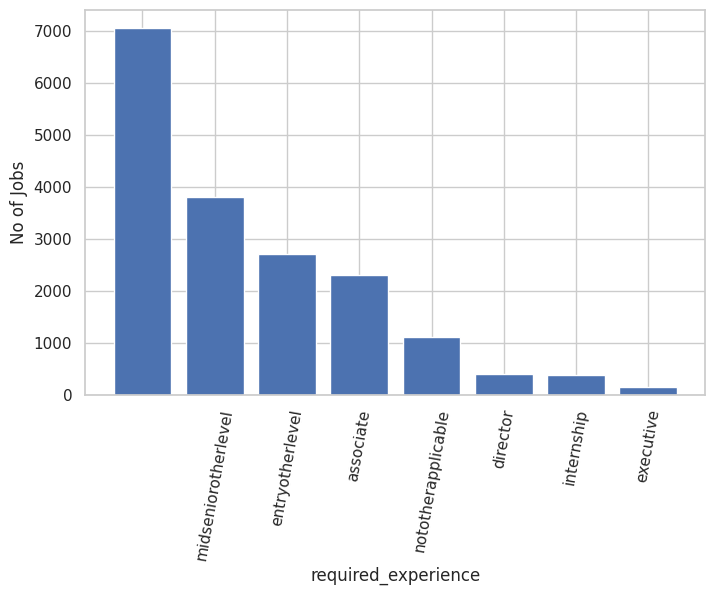

In [ ]:
required_experience = dict(df.required_experience.value_counts().head(10))


plt.figure(figsize=(8,5))
sns.set_theme(style='whitegrid')
plt.bar(required_experience.keys(),required_experience.values())
plt.xlabel("required_experience")
plt.ylabel("No of Jobs")
plt.xticks(rotation=80)
plt.show()

In [ ]:
x = df.required_experience.value_counts().head(20)

In [ ]:
x = dict(x).keys()
x = list(x)

In [ ]:
def correct_required_experience(data):
  if data in x[1:]:
    return data
  else:
    return 'other'

In [ ]:
df['required_experience'] = df['required_experience'].apply(correct_required_experience)

In [ ]:
df.required_experience.value_counts().head(20)

,count
required_experience,
other,7050
midseniorotherlevel,3809
entryotherlevel,2697
associate,2297
nototherapplicable,1116
director,389
internship,381
executive,141


In [ ]:
def correct_employment_type(data):
  if 'fulltime' in str(data):
    return "fulltime"
  elif 'contract' in str(data):
    return 'contract'
  elif 'parttime' in str(data):
    return "parttime"
  elif 'temporary' in str(data):
    return "temporary"
  else:
    return 'other'

In [ ]:
df['employment_type'] = df['employment_type'].apply(correct_employment_type)

In [ ]:
df.employment_type.value_counts().head(20)

,count
employment_type,
other,17880


In [ ]:
df['employment_type'] = df['employment_type'].str.lower()
df['employment_type'] = df['employment_type'].str.strip()
df['employment_type'] = df['employment_type'].str.replace('\n', '')
df['employment_type'] = df['employment_type'].str.replace('\r', '')
df['employment_type'] = df['employment_type'].str.replace('\t', '')
df['employment_type'] = df['employment_type'].str.replace(' ', 'other')

In [ ]:
df['employment_type'] = df['employment_type'].str.replace(r'[^a-zA-Z]', '', regex=True)

In [ ]:
df['required_education'].fillna("Unspecified", inplace=True)

/tmp/ipython-input-2266817505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['required_education'].fillna("Unspecified", inplace=True)


In [ ]:
df['required_education'] = df['required_education'].str.lower()
df['required_education'] = df['required_education'].str.strip()
df['required_education'] = df['required_education'].str.replace('\n', '')
df['required_education'] = df['required_education'].str.replace('\r', '')
df['required_education'] = df['required_education'].str.replace(',', '')
df['required_education'] = df['required_education'].str.replace('/', '')
df['required_education'] = df['required_education'].str.replace(' ', '')

In [ ]:
def correct_required_education(data):
  if 'bachelor' in str(data):
    return "bachelor"
  elif 'master' in str(data):
    return 'master'
  elif 'highschool' in str(data):
    return "highschool"
  else:
    return 'unspecified'

In [ ]:
df['required_education'] = df['required_education'].apply(correct_required_education)

In [ ]:
df.required_education.value_counts().head(20)

,count
required_education,
unspecified,10212
bachelor,5145
highschool,2107
master,416


In [ ]:
label_encoder = LabelEncoder()

In [ ]:
df['employment_type'] = label_encoder.fit_transform(df['employment_type'])
df['required_education'] = label_encoder.fit_transform(df['required_education'])
df['required_experience'] = label_encoder.fit_transform(df['required_experience'])

In [ ]:
df.head(10)

,title,salary_range,company_profile,description,requirements,benefits,has_company_logo,has_questions,employment_type,required_experience,required_education,fraudulent
0,Marketing Intern,45000.0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,1,0,0,4,3,0
1,Customer Service - Cloud Video Production,45000.0,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,1,0,0,6,3,0
2,Commissioning Machinery Assistant (CMA),45000.0,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,1,0,0,7,3,0
3,Account Executive - Washington DC,45000.0,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,1,0,0,5,0,0
4,Bill Review Manager,45000.0,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,1,1,0,5,0,0
5,Accounting Clerk,45000.0,,Job OverviewApex is an environmental consultin...,,,0,0,0,7,3,0
6,Head of Content (m/f),24000.0,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,1,1,0,5,2,0
7,Lead Guest Service Specialist,45000.0,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,1,1,0,7,3,0
8,HP BSM SME,45000.0,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,,1,1,0,0,3,0
9,Customer Service Associate - Part Time,45000.0,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,,1,0,0,2,1,0


In [ ]:
df.columns

Index(['title', 'salary_range', 'company_profile', 'description',
       'requirements', 'benefits', 'has_company_logo', 'has_questions',
       'employment_type', 'required_experience', 'required_education',
       'fraudulent'],
      dtype='object')

In [ ]:
df['text'] = df['title'] + ' ' + df['company_profile'] + ' ' + df['description'] + ' ' + df['requirements'] + ' ' + df['benefits']
new_df = df.copy()

In [ ]:
new_df = new_df.drop(['title','company_profile','description','requirements','benefits'],axis=1)

In [ ]:
new_df.columns

Index(['salary_range', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'fraudulent', 'text'],
      dtype='object')

In [ ]:
new_df = new_df[['text', 'salary_range',"has_questions", 'has_company_logo','employment_type','required_experience', 'required_education', 'fraudulent']]

In [ ]:
new_df.head(5)

,text,salary_range,has_questions,has_company_logo,employment_type,required_experience,required_education,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",45000.0,0,1,0,4,3,0
1,Customer Service - Cloud Video Production 90 S...,45000.0,0,1,0,6,3,0
2,Commissioning Machinery Assistant (CMA) Valor ...,45000.0,0,1,0,7,3,0
3,Account Executive - Washington DC Our passion ...,45000.0,0,1,0,5,0,0
4,Bill Review Manager SpotSource Solutions LLC i...,45000.0,1,1,0,5,0,0


In [ ]:
new_df.dtypes

,0
text,object
salary_range,float64
has_questions,int64
has_company_logo,int64
employment_type,int64
required_experience,int64
required_education,int64
fraudulent,int64


# Text Data Preprocessing

In [ ]:
import re
import operator
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def remove_stopwords(tweet):
    stop_words = set(stopwords.words('english'))
    words = tweet.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = remove_stopwords(text)
    # Remove numeric data
    text = re.sub(r"\d+", "", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # Remove special characters and punctuation
    text = re.sub(r"[^\w\s]", "", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    # Remove Non-ASCII
    text = ''.join(char for char in text if ord(char) < 128)
    return text.strip()

In [ ]:
new_df['text_c'] = new_df['text'].apply(clean_text)

In [ ]:
new_df.columns

Index(['text', 'salary_range', 'has_questions', 'has_company_logo',
       'employment_type', 'required_experience', 'required_education',
       'fraudulent', 'text_c'],
      dtype='object')

In [ ]:
new_df = new_df[['text', 'text_c','salary_range','has_questions', 'has_company_logo','employment_type','required_experience', 'required_education', 'fraudulent']]

In [ ]:
new_df.head(10)

,text,text_c,salary_range,has_questions,has_company_logo,employment_type,required_experience,required_education,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...,45000.0,0,1,0,4,3,0
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...,45000.0,0,1,0,6,3,0
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...,45000.0,0,1,0,7,3,0
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...,45000.0,0,1,0,5,0,0
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc g...,45000.0,1,1,0,5,0,0
5,Accounting Clerk Job OverviewApex is an envi...,accounting clerk job overviewapex environmenta...,45000.0,0,0,0,7,3,0
6,"Head of Content (m/f) Founded in 2009, the Fon...",head content mf founded fonpit ag rose interna...,24000.0,1,1,0,5,2,0
7,Lead Guest Service Specialist Airenvy’s mis...,lead guest service specialist airenvys mission...,45000.0,1,1,0,7,3,0
8,HP BSM SME Solutions3 is a woman-owned small b...,hp bsm sme solutions womanowned small business...,45000.0,1,1,0,0,3,0
9,Customer Service Associate - Part Time Novite...,customer service associate part time novitex e...,45000.0,0,1,0,2,1,0


In [ ]:
new_df.shape

(17880, 9)

# Word Embedding

In [ ]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences
!pip install gensim
from gensim.models import Word2Vec
import nltk
nltk.download('punkt')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('punkt_tab')

# Preprocess the text data
tokenized_text = new_df['text_c'].apply(lambda x: word_tokenize(x.lower()))

# Train Word2Vec model
model = Word2Vec(tokenized_text, vector_size=300, window=5, min_count=1, workers=4)

# Function to get the vector for a sentence
def get_sentence_vector(sentence):
    vector = np.zeros(300)
    tokens = word_tokenize(sentence.lower())
    vector += sum([model.wv[word] for word in tokens if word in model.wv])
    return vector

# Apply Word2Vec to each text entry in the DataFrame
vectors = new_df['text_c'].apply(get_sentence_vector)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
vectors

,text_c
0,"[-39.92173385620117, 29.463376998901367, 0.851..."
1,"[-149.8731689453125, -16.21995735168457, 61.40..."
2,"[11.115976333618164, -45.82077407836914, -30.5..."
3,"[-0.5230333805084229, -87.33048248291016, -101..."
4,"[33.66856384277344, -40.20027160644531, -114.3..."
...,...
17875,"[-73.02066802978516, 34.66106033325195, 42.400..."
17876,"[-29.358844757080078, -31.611448287963867, -30..."
17877,"[46.56229782104492, -7.362423896789551, -57.44..."
17878,"[50.672855377197266, 13.721763610839844, 31.70..."


In [ ]:
padded_vectors_text = pad_sequences(vectors, maxlen=300, padding='post', truncating='post')

In [ ]:
numerical_x = new_df.drop(['fraudulent','text_c','text'],axis=1)
label = new_df['fraudulent']

In [ ]:
combined_x = np.concatenate((padded_vectors_text, numerical_x), axis=1)

In [ ]:
combined_x.shape

(17880, 306)

# Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
X =  new_df.drop(['fraudulent','text_c','text'],axis=1)
label =new_df['fraudulent']

In [ ]:
oversampler = SMOTE(random_state=42)

In [ ]:
sampled_x, sampled_y = oversampler.fit_resample(combined_x,label)

In [ ]:
sampled_x.shape, sampled_y.shape

((34028, 306), (34028,))

# Data Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sampled_x, sampled_y, test_size=0.20, random_state=42)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)

predicted_labels = random_forest.predict(X_test,)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)

print(f"Accuracy: {accuracy}%")


Accuracy: 99.37%


In [ ]:
y_pred_rf = random_forest.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3396
           1       0.99      1.00      0.99      3410

    accuracy                           0.99      6806
   macro avg       0.99      0.99      0.99      6806
weighted avg       0.99      0.99      0.99      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)



classes = np.unique(y_train)


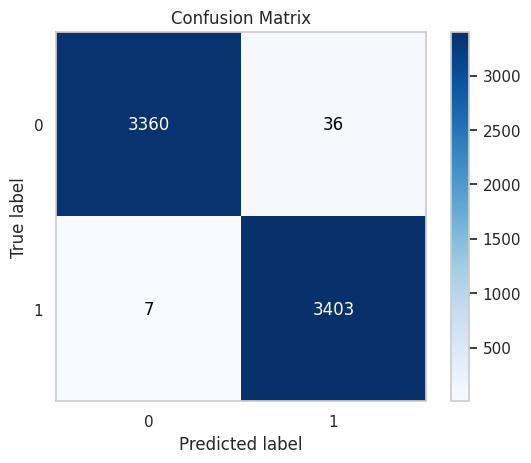

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()
ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


svm = SVC()
svm.fit(X_train, y_train)
predicted_labels = svm.predict(X_test)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)

print(f"Accuracy: {accuracy}%")


Accuracy: 50.44%


In [ ]:
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      3396
           1       0.88      0.01      0.02      3410

    accuracy                           0.50      6806
   macro avg       0.69      0.51      0.35      6806
weighted avg       0.69      0.50      0.35      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)



classes = np.unique(y_train)

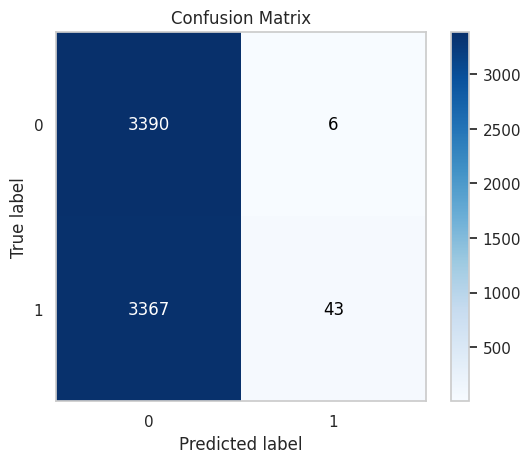

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()


ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier


id3_tree = DecisionTreeClassifier(criterion='entropy')
id3_tree.fit(X_train, y_train)
predicted_labels = id3_tree.predict(X_test)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)

print(f"Accuracy: {accuracy}%")


Accuracy: 96.97%


In [ ]:
y_pred_dt = id3_tree.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3396
           1       0.96      0.98      0.97      3410

    accuracy                           0.97      6806
   macro avg       0.97      0.97      0.97      6806
weighted avg       0.97      0.97      0.97      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)



classes = np.unique(y_train)

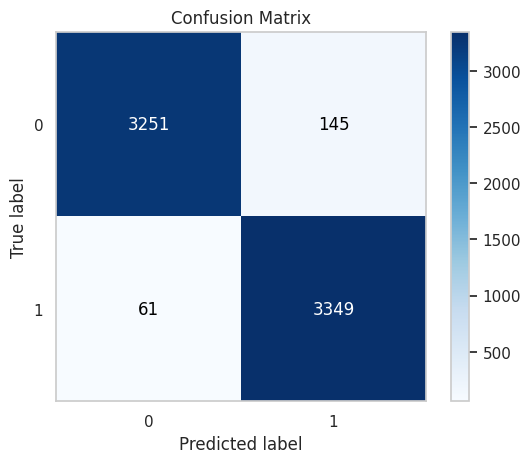

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()


ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()


# XGB

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train, y_train)
predicted_labels = xgb_classifier.predict(X_test)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)

print(f"Accuracy: {accuracy}%")


Accuracy: 99.44%


In [ ]:
y_pred_xgb = xgb_classifier.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3396
           1       0.99      1.00      0.99      3410

    accuracy                           0.99      6806
   macro avg       0.99      0.99      0.99      6806
weighted avg       0.99      0.99      0.99      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)



classes = np.unique(y_train)

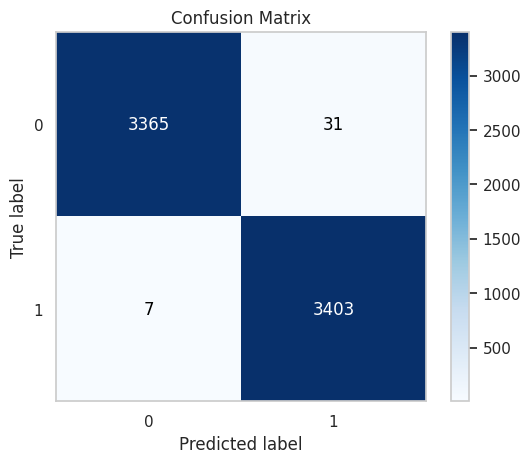

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()


ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()


# LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
predicted_labels = logistic_regression.predict(X_test)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(f"Accuracy: {accuracy}%")

Accuracy: 79.44%


In [ ]:
y_pred_lr = logistic_regression.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      3396
           1       0.80      0.78      0.79      3410

    accuracy                           0.79      6806
   macro avg       0.79      0.79      0.79      6806
weighted avg       0.79      0.79      0.79      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)


classes = np.unique(y_train)

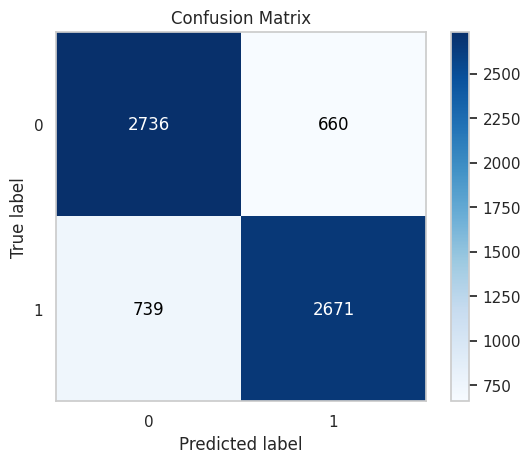

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()


ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()


# KNN

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
predicted_labels = knn.predict(X_test)
accuracy = round(accuracy_score(y_test, predicted_labels) * 100, 2)

print(f"Accuracy: {accuracy}%")


Accuracy: 93.95%


In [ ]:
y_pred_knn = knn.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3396
           1       0.89      1.00      0.94      3410

    accuracy                           0.94      6806
   macro avg       0.95      0.94      0.94      6806
weighted avg       0.95      0.94      0.94      6806



In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)


classes = np.unique(y_train)

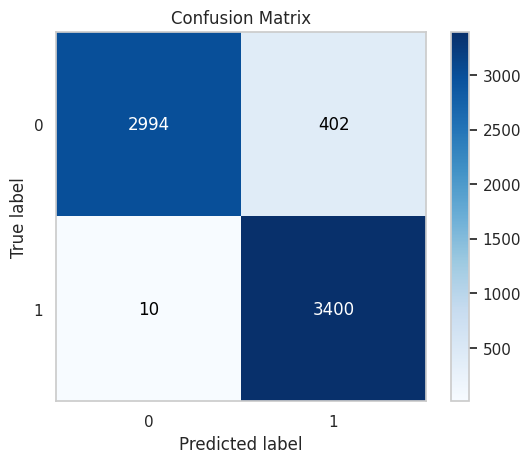

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots()


ax.grid(False)


im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(title='Confusion Matrix',
       xlabel='Predicted label',
       ylabel='True label')

tick_marks = np.arange(len(classes))
ax.set(xticks=tick_marks, xticklabels=classes,
       yticks=tick_marks, yticklabels=classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()


# Deep Learning Models

In [ ]:

X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [ ]:
# Convert integer NumPy arrays to float32
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

# ANN

In [ ]:
# Define the ANN architecture
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         2,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,537 (9.91 KB)

 Trainable params: 2,537 (9.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5096 - loss: 0.6942 - val_accuracy: 0.5053 - val_loss: 0.6916
Epoch 2/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4973 - loss: 0.6858 - val_accuracy: 0.5191 - val_loss: 0.6805
Epoch 3/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5218 - loss: 0.6774 - val_accuracy: 0.5215 - val_loss: 0.6753
Epoch 4/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5159 - loss: 0.6808 - val_accuracy: 0.5187 - val_loss: 0.6819
Epoch 5/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5257 - loss: 0.6756 - val_accuracy: 0.5195 - val_loss: 0.6758
Epoch 6/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5266 - loss: 0.6744 - val_accuracy: 0.5210 - val_loss: 0.6742
Epoch 7/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5308 - loss: 0.6728 - val_accuracy: 0.5210 - val_loss: 0.6767
Epoch 8/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5209 - loss: 0.6746 - val_accuracy: 0

In [ ]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

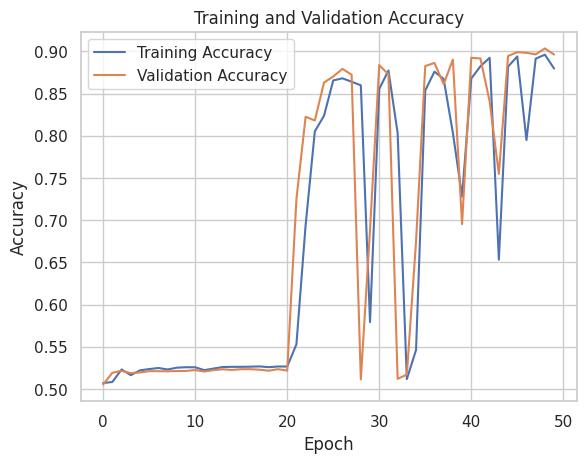

In [ ]:

plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

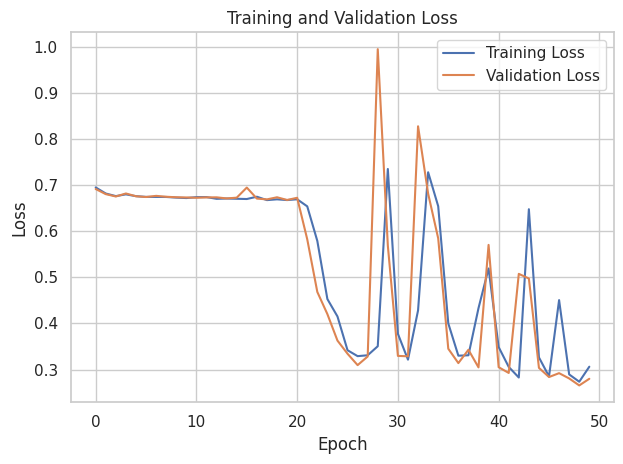

In [ ]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

predicted_labels = np.round(model.predict(X_train))
accuracy = round(accuracy_score(y_train, predicted_labels) * 100, 2)

print(f"Training Accuracy: {accuracy}%")


predicted_labels_val = np.round(model.predict(X_test))
accuracy_val = round(accuracy_score(y_test, predicted_labels_val) * 100, 2)

print(f"Validation Accuracy: {accuracy_val}%")

851/851 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training Accuracy: 90.17%
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Validation Accuracy: 89.63%


In [ ]:

predicted_labels = np.round(model.predict(X_test))
predicted_labels = np.squeeze(predicted_labels)


classification_rep = classification_report(y_test, predicted_labels)

print("Classification Report:")
print(classification_rep)

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90      3396
         1.0       0.89      0.90      0.90      3410

    accuracy                           0.90      6806
   macro avg       0.90      0.90      0.90      6806
weighted avg       0.90      0.90      0.90      6806



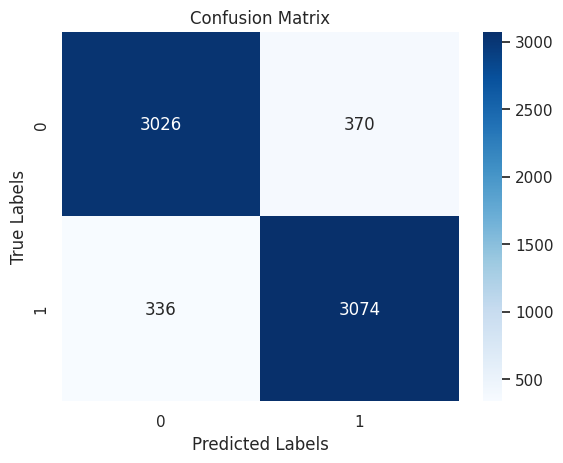

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

confusion_mat = confusion_matrix(y_test, predicted_labels)


sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# LSTM

In [ ]:
import numpy as np
from tensorflow import keras


X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


model = keras.Sequential([
    keras.layers.LSTM(16, input_shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 77s 85ms/step - accuracy: 0.6356 - loss: 0.6363 - val_accuracy: 0.7533 - val_loss: 0.5033
Epoch 2/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.7702 - loss: 0.4962 - val_accuracy: 0.7997 - val_loss: 0.4698
Epoch 3/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.7909 - loss: 0.4646 - val_accuracy: 0.8130 - val_loss: 0.4316
Epoch 4/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8201 - loss: 0.4194 - val_accuracy: 0.8353 - val_loss: 0.4019
Epoch 5/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 70s 82ms/step - accuracy: 0.8368 - loss: 0.3918 - val_accuracy: 0.8462 - val_loss: 0.3807
Epoch 6/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 70s 82ms/step - accuracy: 0.8461 - loss: 0.3660 - val_accuracy: 0.8572 - val_loss: 0.3550
Epoch 7/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 70s 83ms/step - accuracy: 0.8513 - loss: 0.3544 - val_accuracy: 0.8648 - val_loss: 0.3484
Epoch 8/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8648 - loss: 0.3314 - 

In [ ]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

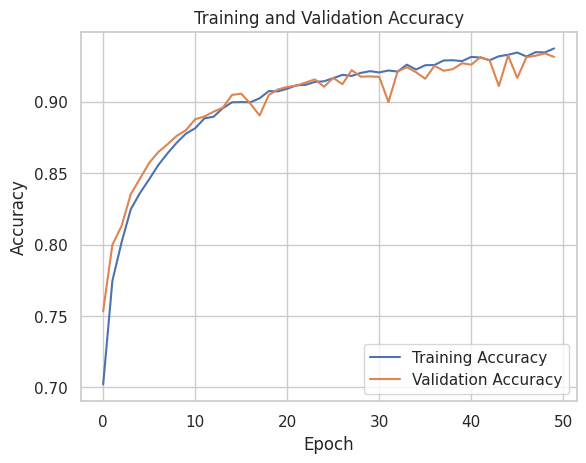

In [ ]:


plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

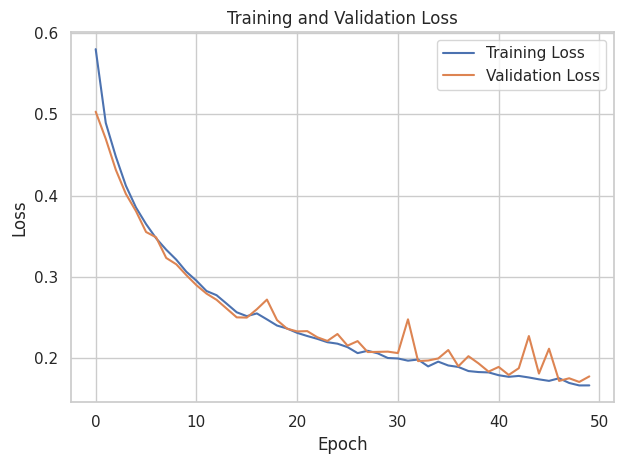

In [ ]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

predicted_labels = np.round(model.predict(X_train))
accuracy = round(accuracy_score(y_train, predicted_labels) * 100, 2)

print(f"Training Accuracy: {accuracy}%")


predicted_labels_val = np.round(model.predict(X_test))
accuracy_val = round(accuracy_score(y_test, predicted_labels_val) * 100, 2)

print(f"Validation Accuracy: {accuracy_val}%")

851/851 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step
Training Accuracy: 93.88%
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Validation Accuracy: 93.14%


In [ ]:

predicted_labels = np.round(model.predict(X_test))
predicted_labels = np.squeeze(predicted_labels)

classification_rep = classification_report(y_test, predicted_labels)

print("Classification Report:")
print(classification_rep)

213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      3396
         1.0       0.91      0.96      0.93      3410

    accuracy                           0.93      6806
   macro avg       0.93      0.93      0.93      6806
weighted avg       0.93      0.93      0.93      6806



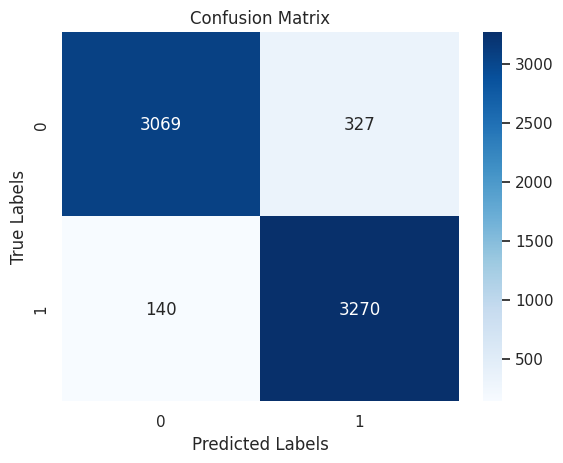

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

confusion_mat = confusion_matrix(y_test, predicted_labels)


sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()